<a href="https://colab.research.google.com/github/Hemanthb1/GW_AGN_watcher/blob/main/watcher_dashboard_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ⚙️ Setup

### 1. Clone the Dashboard Repo

This notebook is part of the **GW-AGN Dashboard** pipeline:

> 🔭 **Dashboard:** [gw-agn-dashboard.vercel.app](https://gw-agn-dashboard.vercel.app)  
> 📦 **Repo:** [github.com/Hemanthb1/gw-agn-dashboard](https://github.com/Hemanthb1/gw-agn-dashboard)

First, fork and clone the repo:

1. Go to [github.com/Hemanthb1/gw-agn-dashboard](https://github.com/Hemanthb1/gw-agn-dashboard)
2. Click **Fork** (top right) to create your own copy
3. Update the `REPO` variable in the config cell below to point to your fork:
```python
   REPO = "your-username/gw-agn-dashboard"
```

### 2. GitHub Token (required to push results)

Pipeline outputs (`final_candidates.csv`, `skymap_contours.csv`) are pushed directly
to the repo via the GitHub API — the Vercel dashboard updates automatically once pushed.

To enable pushing:
1. Go to **Colab → Tools → Secrets** (🔑 icon in left sidebar)
2. Add a secret named `GITHUB_TOKEN`
3. Set the value to a GitHub Personal Access Token with **`repo` scope**
   - Generate one at: GitHub → Settings → Developer Settings → Personal Access Tokens → Classic
4. Enable notebook access for the secret

> ⚠️ Never paste your token directly into the notebook code.

### 3. Install dependencies

```python
!pip install gw_agn_watcher
```

### 4. Run order

Run cells top to bottom. The final **"Save & Push"** cell will push results to your
fork of [gw-agn-dashboard](https://github.com/Hemanthb1/gw-agn-dashboard) and the
dashboard will reflect the updates automatically.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
file='/content/drive/MyDrive/milqd.csv'

In [4]:
urls3 = ["https://gracedb.ligo.org/api/superevents/S251117dq/files/Bilby.multiorder.fits",
       "https://gracedb.ligo.org/api/superevents/S251116en/files/Bilby.multiorder.fits",
       "https://gracedb.ligo.org/api/superevents/S251112cm/files/Bilby.multiorder.fits",
       "https://gracedb.ligo.org/api/superevents/S251108fi/files/Bilby.multiorder.fits",
       "https://gracedb.ligo.org/api/superevents/S251108dn/files/Bilby.multiorder.fits",
       "https://gracedb.ligo.org/api/superevents/S251105aj/files/Bilby.multiorder.fits",
       "https://gracedb.ligo.org/api/superevents/S251103f/files/Bilby.multiorder.fits",
       "https://gracedb.ligo.org/api/superevents/S251031cq/files/Bilby.multiorder.fits",
       "https://gracedb.ligo.org/api/superevents/S251026bn/files/Bilby.multiorder.fits",
       "https://gracedb.ligo.org/api/superevents/S251021u/files/Bilby.multiorder.fits",
       "https://gracedb.ligo.org/api/superevents/S251018bi/files/Bilby.multiorder.fits",
    "https://gracedb.ligo.org/api/superevents/S251014cn/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S251013x/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S251006dd/files/bayestar.multiorder.fits,2",
    "https://gracedb.ligo.org/api/superevents/S250929c/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250927cy/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250927ck/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250920bq/files/bayestar.multiorder.fits,1",
    "https://gracedb.ligo.org/api/superevents/S250917aq/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250912f/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250911ac/files/Bilby.offline0.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250910b/files/bayestar.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250908y/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250906ca/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250904cv/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250904br/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250904ae/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250901cb/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250830bp/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250830m/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250827fo/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250827l/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250818t/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250813k/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250810ck/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250802dn/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250727dc/files/Bilby.offline0.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250727cl/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250726ak/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250725l/files/Bilby.offline0.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250725j/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250712cd/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250711q/files/Bilby.offline1.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250705cb/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250704ab/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250702n/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250701bq/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250701bp/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250629bs/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250629ae/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250628am/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250331o/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250328ae/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250326y/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250319bu/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250304cb/files/bayestar.multiorder.fits,2",
    "https://gracedb.ligo.org/api/superevents/S250227y/files/bayestar.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250227e/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250226dl/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250221gb/files/bayestar.multiorder.fits,1",
    "https://gracedb.ligo.org/api/superevents/S250221eb/files/bayestar.multiorder.fits,1",
    "https://gracedb.ligo.org/api/superevents/S250211be/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250211aa/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250208ad/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250207bg/files/Bilby.offline1.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250206dm/files/Bilby.offline1.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250205ee/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250205bk/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250204ax/files/Bilby.multiorder.fits,0",
    "https://gracedb.ligo.org/api/superevents/S250202cu/files/Bilby.multiorder.fits,0"
]

In [5]:
pip install gw_agn_watcher

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 46.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 10.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 6.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.8/754.8 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.0/191.0

In [6]:
from gw_agn_watcher.main_pipeline import run_pipeline
from gw_agn_watcher.main_pipeline import radecligo
from gw_agn_watcher.main_pipeline import redshift


# Generate skymaps for the dashboard

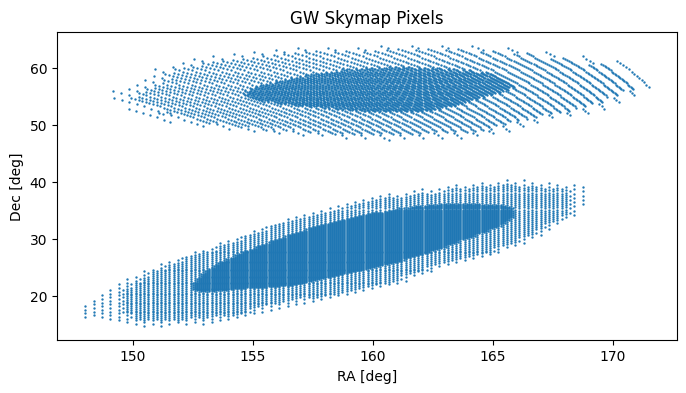

k = 2.887
⚠️ S251031cq: distance_lower2 below 0.01 Mpc, setting z_min2=0.0
Event: S251031cq
Mean distance: 2137.09 ± 740.25 Mpc
Redshift range (1.28σ): 0.2946 – 0.8918
Redshift range (2σ): 0.1573 – 1.1051
Redshift range (kσ): 0.0000 – 1.4086


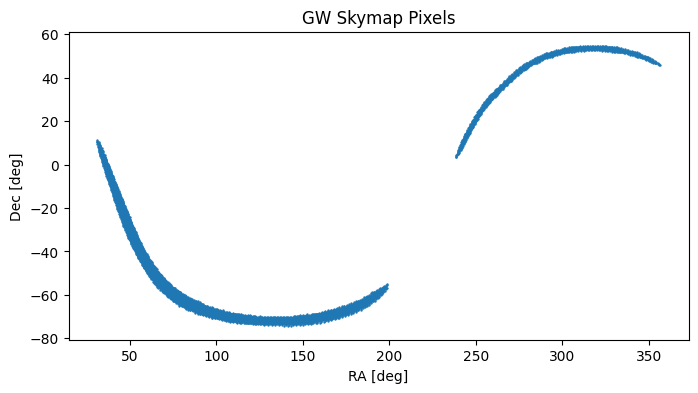

k = 3
Event: S251026bn
Mean distance: 1207.01 ± 349.15 Mpc
Redshift range (1.28σ): 0.1832 – 0.4231
Redshift range (2σ): 0.1208 – 0.4968
Redshift range (kσ): 0.0372 – 0.6045


In [42]:
all_skymaps=[]
for x in urls3[7:9]:
  try:
    skymap, df, ra, dec, mjd, event = radecligo.radecligo(x, plot=True)
    df['event_id']=event

    results=redshift.compute_distance_redshift(x)
    df['distmean']=results['distmean_Mpc']
    df['diststd']=results['diststd_Mpc']
    df['z_min']=results['z_min1']
    df['z_max']=results['z_max1']

    all_skymaps.append(df)


  except Exception as e:
        print(f" Failed for {x}: {e}")
        continue

skymaps=pd.concat(all_skymaps)
skymaps.to_csv("skymaps.csv", index=False)

#Generate candidates for the dashboard/follow-up

🚀 Starting GW–AGN crossmatching pipeline...
🔗 Skymap: https://gracedb.ligo.org/api/superevents/S251031cq/files/Bilby.multiorder.fits
📂 Milliquas catalog: /content/drive/MyDrive/milqd.csv

✅ Loaded skymap 'S251031cq' with 13392 pixels in 90% region.



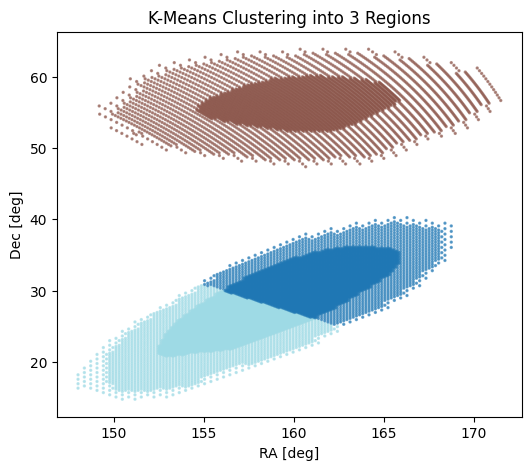

✅ Divided into 13392 clusters (k=3).

✅ Connected to ALeRCE remote database.
querying cluster: 0
querying cluster: 1
querying cluster: 2


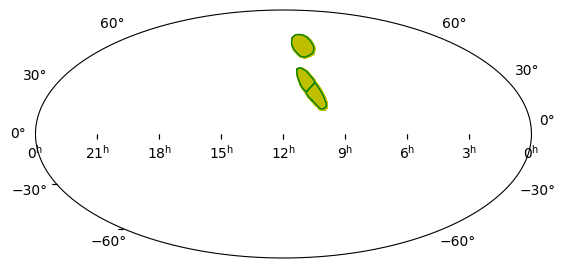

✅ Queried ALeRCE: 139889 sources retrieved from cluster regions.

Matched 243 candidates to Milliquas within 2.9 arcsec.
Results saved to S251031cq_matched_milliquas.csv
✅ Matched with Milliquas: 243 candidate AGNs after spatial crossmatch.

k = 2.887
⚠️ S251031cq: distance_lower2 below 0.01 Mpc, setting z_min2=0.0
Event: S251031cq
Mean distance: 2137.09 ± 740.25 Mpc
Redshift range (1.28σ): 0.2946 – 0.8918
Redshift range (2σ): 0.1573 – 1.1051
Redshift range (kσ): 0.0000 – 1.4086
1.28σ AGNs: 35 | 2σ AGNs: 74 | kσ AGNs: 129
✅ Redshift filtering complete: 74 objects remain within 2sigma distance.

✅ Connected to ALeRCE remote database.
🔍 Running 1 batch(es) for 74 OIDs (batch_size=10000)...
✅ Batch 1/1: stamp=55, lc=18

🏁 Final combined sample: 56 objects.
✅ Classifiers queried: 56 objects classified (stamp/lc).

✅ Retrieved 5 detections after filtering.
✅ Detections queried: 5 rows retrieved from database.

✅ Merged classifiers + detections: 5 objects.

✅ SFD maps already exist, skipping

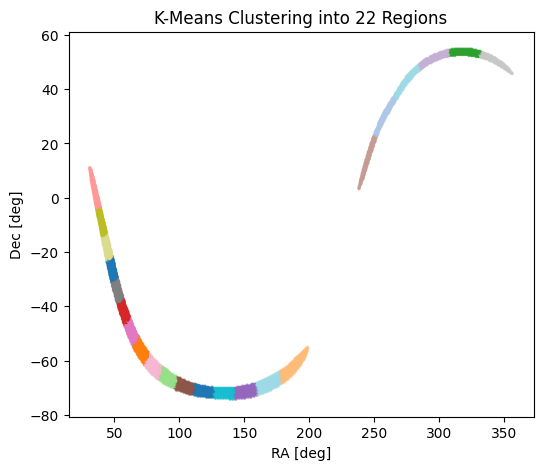

✅ Divided into 14081 clusters (k=22).

✅ Connected to ALeRCE remote database.
querying cluster: 0
querying cluster: 1
querying cluster: 2
querying cluster: 3
querying cluster: 4
querying cluster: 5
querying cluster: 6
querying cluster: 7
querying cluster: 8
querying cluster: 9
querying cluster: 10
querying cluster: 11
querying cluster: 12
querying cluster: 13
querying cluster: 14
querying cluster: 15
querying cluster: 16
querying cluster: 17
querying cluster: 18
querying cluster: 19
querying cluster: 20
querying cluster: 21


ValueError: 'vertices' must be 2D with shape (N, 2), but your input has shape (2, 0)

<Figure size 640x480 with 1 Axes>

✅ Queried ALeRCE: 39997 sources retrieved from cluster regions.

Matched 32 candidates to Milliquas within 2.9 arcsec.
Results saved to S251026bn_matched_milliquas.csv
✅ Matched with Milliquas: 32 candidate AGNs after spatial crossmatch.

k = 3
Event: S251026bn
Mean distance: 1207.01 ± 349.15 Mpc
Redshift range (1.28σ): 0.1832 – 0.4231
Redshift range (2σ): 0.1208 – 0.4968
Redshift range (kσ): 0.0372 – 0.6045
1.28σ AGNs: 0 | 2σ AGNs: 0 | kσ AGNs: 1
⚠️ No AGNs passed the 2sigma redshift cut — stopping early.
✅ Total 4 candidates saved


In [36]:
final = []


for x in urls3[7:9]:
  result = run_pipeline(x, file)
  if len(result) == 4:
    cand = None
  else:
    cand, ra, dec, url, mjd_obs = result

  if cand is None or cand.empty:
      continue

  # Get skymap contours

  # Add metadata
  cand["event_url"] = url
  cand["mjd_obs"] = mjd_obs
  final.append(cand)


# Combine all candidates
combined = pd.concat(final, ignore_index=True)
combined = combined.drop_duplicates(subset=["oid", "event_id"])
print(f"✅ Total {len(combined)} candidates saved")


# Save skymap contours


In [33]:
# ── GitHub Config ────────────────────────────────────────────────
from google.colab import userdata
import requests, base64, json

GITHUB_TOKEN = userdata.get("GITHUB_TOKEN")
REPO = "Hemanthb1/gw-agn-dashboard"
HEADERS = {
    "Authorization": f"token {GITHUB_TOKEN}",
    "Accept": "application/vnd.github.v3+json"
}

def push_csv_to_github(local_path, repo_path, commit_message=None):
    with open(local_path, "rb") as f:
        content = base64.b64encode(f.read()).decode("utf-8")

    url = f"https://api.github.com/repos/{REPO}/contents/{repo_path}"
    response = requests.get(url, headers=HEADERS)

    payload = {
        "message": commit_message or f"Update {repo_path}",
        "content": content,
    }
    if response.status_code == 200:
        payload["sha"] = response.json()["sha"]

    response = requests.put(url, headers=HEADERS, data=json.dumps(payload))
    if response.status_code in [200, 201]:
        print(f"✅ {repo_path} pushed")
    else:
        print(f"❌ {repo_path} failed: {response.json()['message']}")

In [ ]:
# ── Save & Push to GitHub ────────────────────────────────────────
combined.to_csv("final_candidates.csv", index=False)
skymaps.to_csv("skymaps.csv", index=False)

push_csv_to_github("final_candidates.csv", "public/final_candidates.csv")
push_csv_to_github("skymaps.csv",  "pulic/skymap_contours.csv")